In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten,c

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.optimizers import Adam
import pandas as pd

In [2]:
df=pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.shape

(100000, 9)

In [4]:
df.duplicated().sum()

np.int64(3854)

In [5]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


### EDA

<Axes: xlabel='diabetes'>

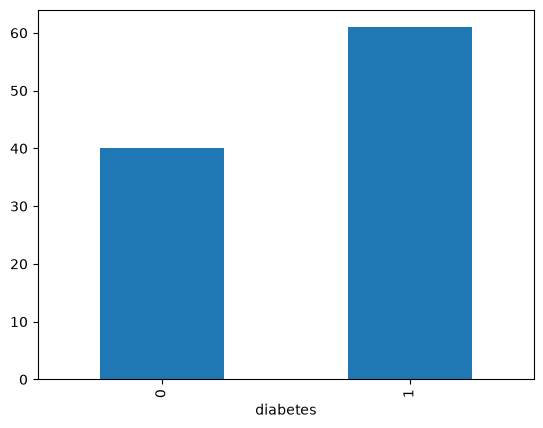

In [7]:
df.groupby('diabetes')['age'].mean().plot(kind='bar')

In [8]:
df['gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

gender    Female   Male  Other
diabetes                      
0          54091  37391     18
1           4461   4039      0


<Axes: xlabel='diabetes'>

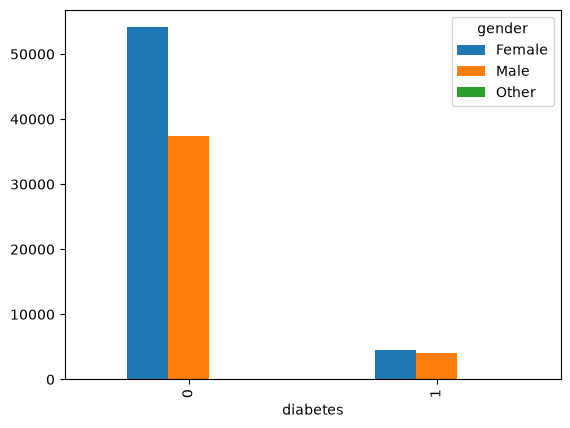

In [9]:
gender_diabetes_counts = pd.crosstab(df['diabetes'], df['gender'])
print(gender_diabetes_counts)
gender_diabetes_counts.plot(kind='bar', stacked=False)

hypertension      0     1
diabetes                 
0             86103  5397
1              6412  2088


<Axes: xlabel='diabetes'>

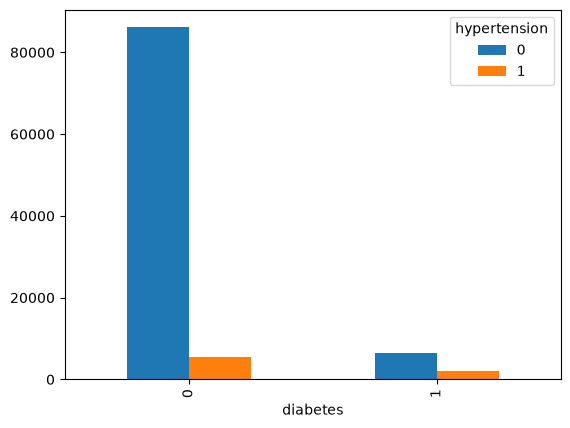

In [10]:
hypertension_diabetes_counts = pd.crosstab(df['diabetes'], df['hypertension'])
print(hypertension_diabetes_counts)
hypertension_diabetes_counts.plot(kind='bar', stacked=False)

<Axes: xlabel='diabetes'>

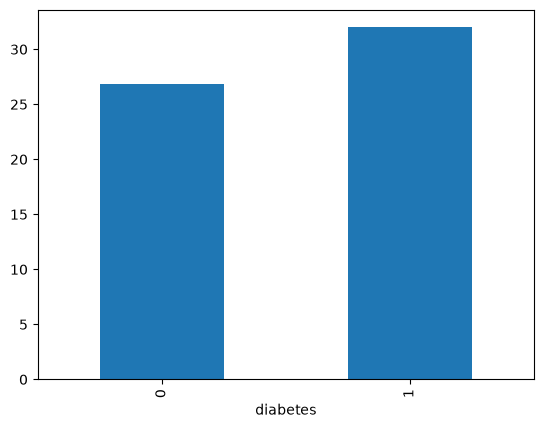

In [11]:
df.groupby('diabetes')['bmi'].mean().plot(kind='bar')

heart_disease      0     1
diabetes                  
0              88825  2675
1               7233  1267


<Axes: xlabel='diabetes'>

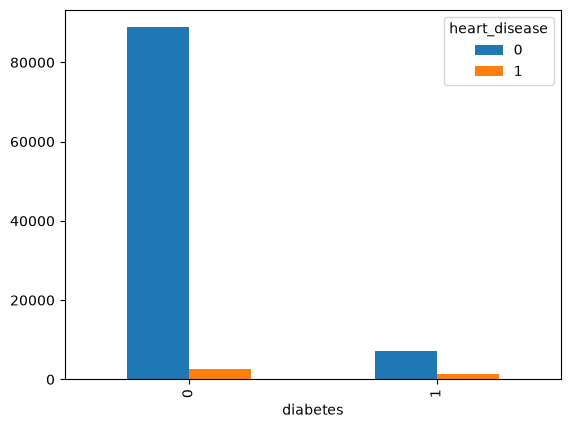

In [12]:
heart_disease_diabetes_counts = pd.crosstab(df['diabetes'], df['heart_disease'])
print(heart_disease_diabetes_counts)
heart_disease_diabetes_counts.plot(kind='bar', stacked=False)

<Axes: xlabel='diabetes'>

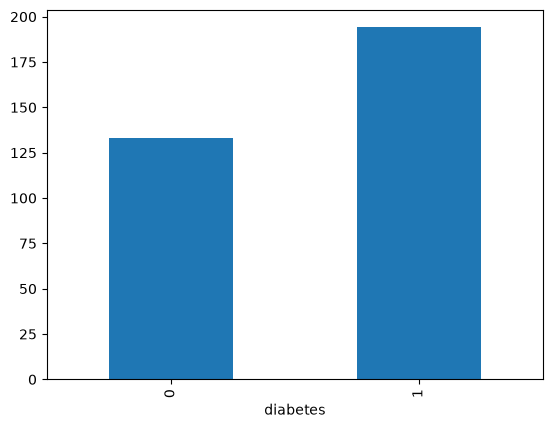

In [13]:
df.groupby('diabetes')['blood_glucose_level'].mean().plot(kind='bar')

<Axes: xlabel='diabetes'>

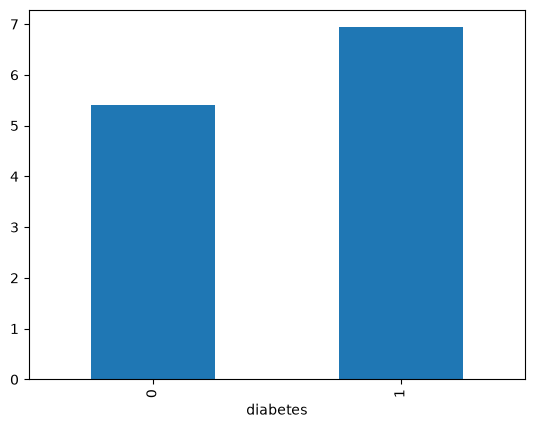

In [14]:
df.groupby('diabetes')['HbA1c_level'].mean().plot(kind='bar')

smoking_history  No Info  current  ever  former  never  not current
diabetes                                                           
0                  34362     8338  3532    7762  31749         5757
1                   1454      948   472    1590   3346          690


<Axes: xlabel='diabetes'>

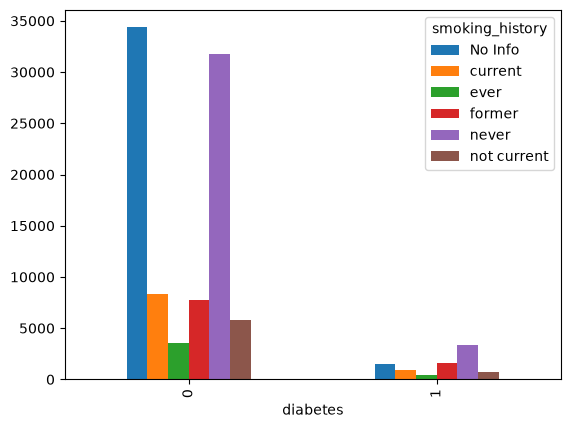

In [15]:
smoking_history_diabetes_counts = pd.crosstab(df['diabetes'], df['smoking_history'])
print(smoking_history_diabetes_counts)
smoking_history_diabetes_counts.plot(kind='bar', stacked=False)

### Find Imbalance Ratio

In [16]:
non_diabetes=df[df["diabetes"] == 0].shape[0]
diabetes=df[df["diabetes"] == 1].shape[0]
imbalance_rattio=non_diabetes/diabetes 
print("Class Imbalance Ratio is : ",imbalance_rattio)

Class Imbalance Ratio is :  10.764705882352942


### Feature Engineering

In [17]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [18]:
cat_feature=[feature for feature in X.columns if df[feature].dtype in ['str']]

In [19]:
num_cols=[feature for feature in X.columns if feature not in cat_feature]

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
                 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_feature)
    ],
    remainder='passthrough' #
)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

X_train_scaled = preprocessor.fit_transform(X_train)

X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

### SIMPLE Model -> Without Optimization

In [21]:
model=Sequential([
    Dense(units=32,activation='relu'),
    Dense(units=8,activation='relu'),
    Dense(units=1,activation='sigmoid')]
)

In [22]:
model.compile(metrics=['accuracy'],loss='binary_crossentropy')

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# import time
# start = time.time()
# history=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100 ,validation_split=0.2)
# print(time.time()-start)

Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9531 - loss: 0.1417
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9616 - loss: 0.1122
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9647 - loss: 0.1053
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9665 - loss: 0.0991
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9681 - loss: 0.0952
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9686 - loss: 0.0927
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9694 - loss: 0.0911
Epoch 8/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9700 - loss: 0.0899
Epoch 9/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9705 - loss: 0.0893
Epoch 10/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9706 - loss: 0.0891
Epoch 11/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9709 - loss: 0.0889
Epoch 12/200
2000/2

In [31]:
# output for above
# Epoch 200/200
# 2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9715 - loss: 0.0933
# 501.4647362232208

In [30]:
y_prob=model.predict(X_test_scaled) 
from sklearn.metrics import accuracy_score
y_pred=y_prob.argmax(axis=1)
accuracy_score(y_test,y_pred)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step


0.9146

In [33]:
print("\n--- Final Test Set Evaluation ---")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


--- Final Test Set Evaluation ---
Test Loss: 0.0928
Test Accuracy: 0.9714


KeyError: 'val_loss'

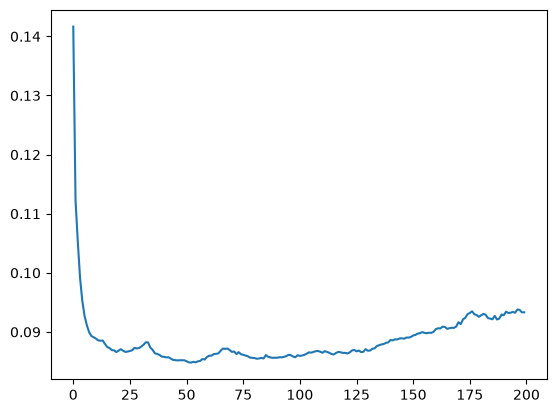

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

### 1. Use Early Stopping

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=10,                
    restore_best_weights=True
)

import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,callbacks=[early_stop],validation_data=[X_val_scaled,y_val],verbose=1)
print(time.time()-start)

Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9531 - loss: 0.1417 - val_accuracy: 0.9595 - val_loss: 0.1188
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9616 - loss: 0.1122 - val_accuracy: 0.9621 - val_loss: 0.1122
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9647 - loss: 0.1053 - val_accuracy: 0.9650 - val_loss: 0.1053
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9665 - loss: 0.0991 - val_accuracy: 0.9659 - val_loss: 0.1003
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9681 - loss: 0.0952 - val_accuracy: 0.9669 - val_loss: 0.0971
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9686 - loss: 0.0927 - val_accuracy: 0.9678 - val_loss: 0.0952
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9694 - loss: 0.0911 - val_accuracy: 0.9686 - val_loss: 0.0938
Epoch 8/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9700 - loss: 0

In [26]:
from sklearn.metrics import accuracy_score
y_prob=model.predict(X_test_scaled) 
y_pred=y_prob.argmax(axis=1)
accuracy_score(y_test,y_pred)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step


0.9146

In [27]:
print("\n--- Final Test Set Evaluation ---")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


--- Final Test Set Evaluation ---
Test Loss: 0.0858
Test Accuracy: 0.9721


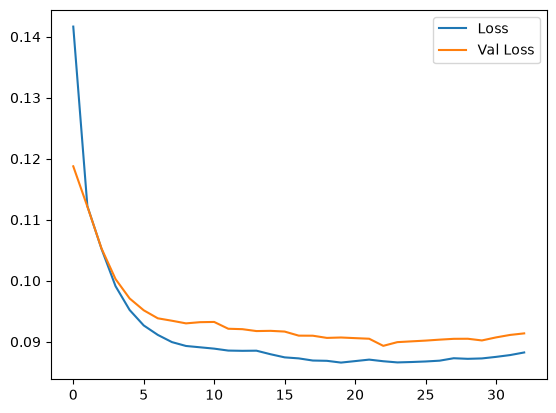

In [31]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

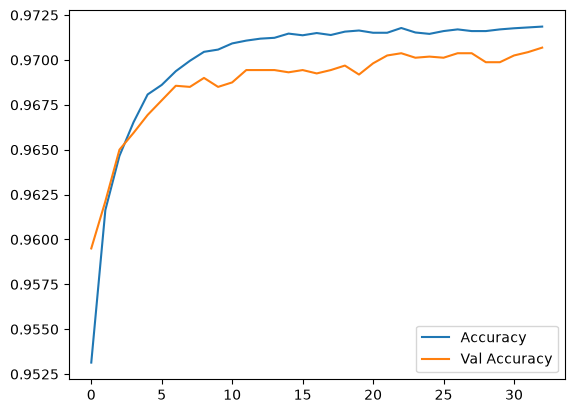

In [32]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy" , "Val Accuracy"])

### Verify for these advantages
#### Prevents Overfitting
#### Improves Generalization
#### Saves Training Time
#### Reduces Computational Resources
#### Automatically Selects the Optimal Number of Training Iterations

### 2. Droupout

In [68]:
model=Sequential([
    Dense(units=32,activation='relu'),
    Dropout(0.3),
    Dense(units=8,activation='relu'),
    Dropout(0.3),
    Dense(units=1,activation='sigmoid')]
)

In [69]:
model.compile(metrics=['accuracy'],loss='binary_crossentropy')

In [ ]:
import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,validation_data=[X_val_scaled,y_val],verbose=1)
print(time.time()-start)

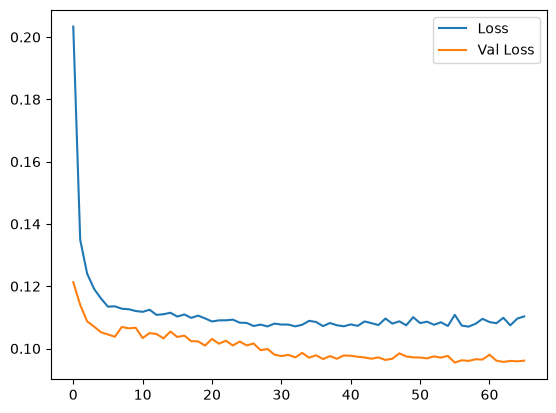

In [71]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

### 3. Using Dropout Without Early Stopping

In [34]:
model=Sequential([
    Dense(units=32,activation='relu'),
    Dropout(0.3),
    Dense(units=8,activation='relu'),
    Dropout(0.3),
    Dense(units=1,activation='sigmoid')]
)

In [35]:
model.compile(metrics=['accuracy'],loss='binary_crossentropy')

In [36]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=10,                
    restore_best_weights=True
)

import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,callbacks=[early_stop],validation_data=[X_val_scaled,y_val],verbose=1)
print(time.time()-start)

Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9320 - loss: 0.2034 - val_accuracy: 0.9588 - val_loss: 0.1213
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9564 - loss: 0.1349 - val_accuracy: 0.9630 - val_loss: 0.1140
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9602 - loss: 0.1240 - val_accuracy: 0.9654 - val_loss: 0.1087
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9625 - loss: 0.1191 - val_accuracy: 0.9660 - val_loss: 0.1070
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9634 - loss: 0.1161 - val_accuracy: 0.9666 - val_loss: 0.1052
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9644 - loss: 0.1134 - val_accuracy: 0.9672 - val_loss: 0.1045
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9642 - loss: 0.1136 - val_accuracy: 0.9672 - val_loss: 0.1038
Epoch 8/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9646 - loss: 0

In [38]:
from sklearn.metrics import accuracy_score
y_prob=model.predict(X_test_scaled) 
y_pred=y_prob.argmax(axis=1)
accuracy_score(y_test,y_pred)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step


0.9146

In [39]:
print("\n--- Final Test Set Evaluation ---")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


--- Final Test Set Evaluation ---
Test Loss: 0.0931
Test Accuracy: 0.9712


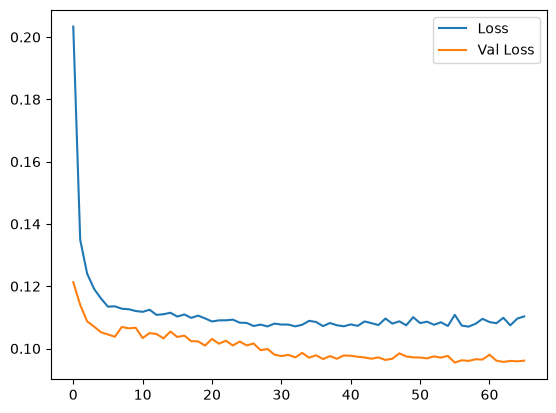

In [41]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [50]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

NameError: name 'history1' is not defined

### Try to validate these 
### Prevents Overfitting
### Improves Generalization
### Reduces Neuron Co-Adaptation
### Acts as a Form of Ensemble Learning
### Improves Model Robustness

### 3. Regularizaion With Early stoping

In [75]:
import tensorflow
model=Sequential([
    Dense(units=32,activation='relu', kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)),
    Dense(units=8,activation='relu' , kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)) ,
    Dense(units=1,activation='sigmoid')]
)

In [76]:
model.compile(metrics=['accuracy'],loss='binary_crossentropy')

In [77]:
import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,validation_data=[X_val_scaled,y_val],verbose=1)
print(time.time()-start)

Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9538 - loss: 0.2034 - val_accuracy: 0.9591 - val_loss: 0.1428
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9596 - loss: 0.1355 - val_accuracy: 0.9593 - val_loss: 0.1362
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0.1313 - val_accuracy: 0.9593 - val_loss: 0.1335
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0.1292 - val_accuracy: 0.9591 - val_loss: 0.1318
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9599 - loss: 0.1278 - val_accuracy: 0.9591 - val_loss: 0.1306
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9599 - loss: 0.1267 - val_accuracy: 0.9592 - val_loss: 0.1297
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0.1259 - val_accuracy: 0.9592 - val_loss: 0.1290
Epoch 8/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0

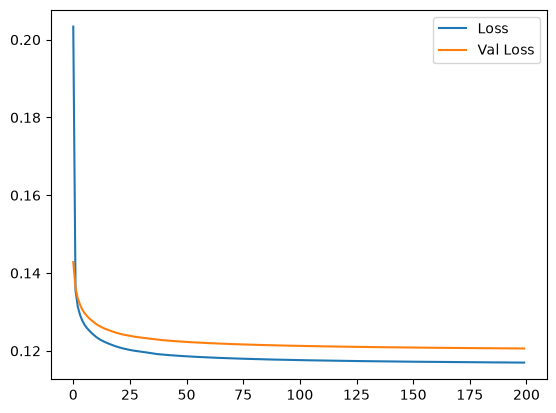

In [78]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [79]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

NameError: name 'history1' is not defined

### BatchNormalization

In [82]:
model=Sequential([
    Dense(units=32,activation='relu'),
    BatchNormalization(),
    Dense(units=8,activation='relu'),
    BatchNormalization(),
    Dense(units=1,activation='sigmoid')]
)

In [83]:
model.compile(metrics=['accuracy'],loss='binary_crossentropy')

In [84]:
import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100f,validation_data=[X_val_scaled,y_val],verbose=1)
print(time.time()-start)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9347 - loss: 0.1834 - val_accuracy: 0.9609 - val_loss: 0.1171
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9586 - loss: 0.1202 - val_accuracy: 0.9616 - val_loss: 0.1125
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9607 - loss: 0.1142 - val_accuracy: 0.9624 - val_loss: 0.1096
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9620 - loss: 0.1105 - val_accuracy: 0.9631 - val_loss: 0.1053
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9628 - loss: 0.1073 - val_accuracy: 0.9635 - val_loss: 0.1038
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9637 - loss: 0.1048 - val_accuracy: 0.9639 - val_loss: 0.1030
Epoch 7/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9653 - loss: 0.1017 - val_accuracy: 0.9651 - val_loss: 0.0999
Epoch 8/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9676 - loss: 0

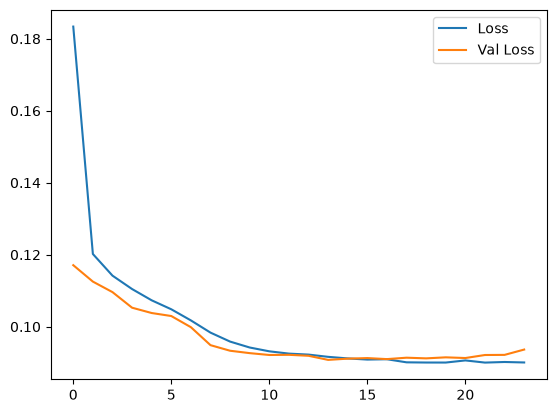

In [85]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

### Using Optimizer

In [86]:
model=Sequential([
    Dense(units=32,activation='relu'),
    Dense(units=8,activation='relu'),
    Dense(units=1,activation='sigmoid')]
)

In [87]:
adam = Adam(learning_rate=0.01)
model.compile(metrics=['accuracy'],loss='binary_crossentropy',optimizer=adam)

In [88]:
import time
start = time.time()
history2=model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,validation_data=[X_val_scaled,y_val],verbose=1)
print("Total time to run model " , time.time()-start)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9603 - loss: 0.1114 - val_accuracy: 0.9684 - val_loss: 0.0908
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9688 - loss: 0.0887 - val_accuracy: 0.9686 - val_loss: 0.0897
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9701 - loss: 0.0865 - val_accuracy: 0.9694 - val_loss: 0.0872
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9707 - loss: 0.0850 - val_accuracy: 0.9699 - val_loss: 0.0868
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9702 - loss: 0.0858 - val_accuracy: 0.9701 - val_loss: 0.0864
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9711 - loss: 0.0840 - val_accuracy: 0.9699 - val_loss: 0.0865
Epoch 7/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9707 - loss: 0.0844 - val_accuracy: 0.9706 - val_loss: 0.0851
Epoch 8/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9712 - loss: 0

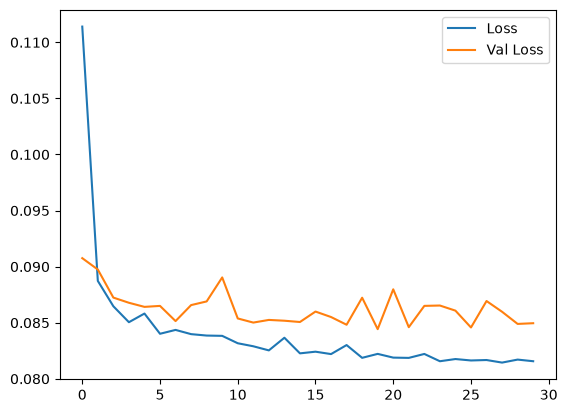

In [89]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [ ]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

### Keras Tuner

In [106]:
import keras_tuner as kt

In [107]:
def model_build(hp):
    model=Sequential()
    
    for i in range(hp.Int('num_layer' , min_value=1, max_value=4)):   
        
        model.add(
            Dense(
                units=hp.Int('unit' + str(i) , min_value=8 , max_value=128 , step=8), 
                activation=hp.Choice('activation' + str(i) , values=['relu','tanh'])
            )
        )
        model.add(
            Dropout(
                hp.Float("dropout"+str(i),0.1,0.4,step=0.1)
            )
        )
        
        
    model.add(Dense(units=1, activation='sigmoid'))
    
    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop"]
    )
    
    learning_rate = hp.Choice(
        "learning_rate",
        [0.01 , 0.1 , 0.5]
    )
    
    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate)
    
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate)

    model.compile(optimizer=optimizer,metrics=['accuracy'],loss='binary_crossentropy')
    return model

In [108]:
tuner=kt.RandomSearch(
    model_build,
    objective='val_accuracy',
    max_trials=20, 
    directory="my_tuner",
    project_name="diabetes"
)

In [109]:
tuner.search(X_train_scaled,
             y_train , 
             validation_split=0.2,
             epochs=50,
             callbacks=[early_stop],
              verbose=1
            )

Trial 20 Complete [00h 01m 25s]
val_accuracy: 0.9693750143051147

Best val_accuracy So Far: 0.9728906154632568
Total elapsed time: 00h 23m 57s


In [110]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hp.values)

{'num_layer': 1, 'unit0': 24, 'activation0': 'relu', 'dropout0': 0.2, 'optimizer': 'adam', 'learning_rate': 0.01, 'unit1': 8, 'activation1': 'tanh', 'dropout1': 0.1, 'unit2': 32, 'activation2': 'tanh', 'dropout2': 0.30000000000000004, 'unit3': 56, 'activation3': 'tanh', 'dropout3': 0.4}


In [111]:
best_model = tuner.get_best_models(num_models=1)[0]

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [112]:
best_model

<Sequential name=sequential, built=True>

In [113]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=10,                
    restore_best_weights=True
)
best_model.fit(X_train_scaled,y_train,batch_size=32,epochs=100,callbacks=[early_stop],validation_split=0.2,verbose=1)

Epoch 1/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9698 - loss: 0.0881 - val_accuracy: 0.9727 - val_loss: 0.0811
Epoch 2/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9703 - loss: 0.0868 - val_accuracy: 0.9728 - val_loss: 0.0812
Epoch 3/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9697 - loss: 0.0868 - val_accuracy: 0.9704 - val_loss: 0.0861
Epoch 4/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9701 - loss: 0.0864 - val_accuracy: 0.9725 - val_loss: 0.0812
Epoch 5/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9698 - loss: 0.0870 - val_accuracy: 0.9724 - val_loss: 0.0813
Epoch 6/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9705 - loss: 0.0864 - val_accuracy: 0.9726 - val_loss: 0.0819
Epoch 7/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9704 - loss: 0.0861 - val_accuracy: 0.9727 - val_loss: 0.0816
Epoch 8/100
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9705 - loss: 0

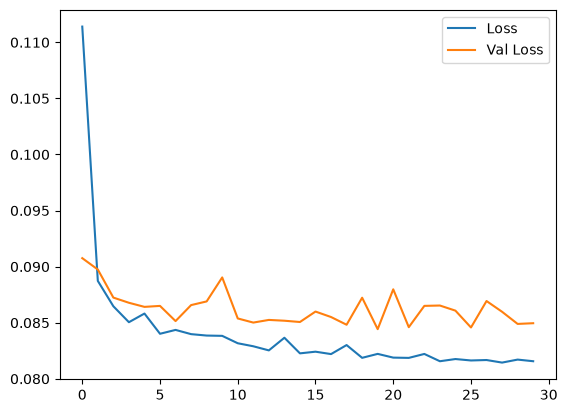

In [114]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(["Loss" , "Val Loss"])

In [81]:
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(["Accuracy for Simple" ,"Accuracy for dropot"  "Val Accuracy for simple", "Val Accuracy for Dropout"])

NameError: name 'history1' is not defined